## Linear Regression Theory: Understanding Weights and Bias

**Linear Regression is a supervised learning algorithm that models the relationship between an input variable (feature) and an output variable (target) by assuming they follow a linear trend (a straight line).**

In [53]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [54]:
"""Aqui estoy definiendo parametros por defecto para evitar repeticion"""
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [55]:
medical_df = pd.read_csv('medical.csv')

## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [56]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

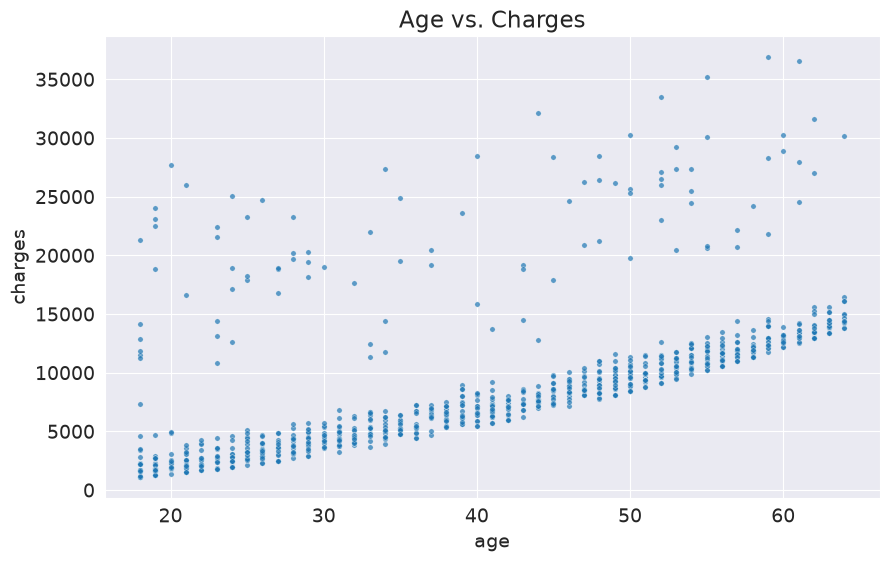

In [ ]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15); # 's' = size of points

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

$y = wx + b$

The line is characterized two numbers: $w$ (called "slope") and $b$ (called "intercept"). 

### Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

$charges = w \times age + b$

We'll try determine $w$ and $b$ for the line that best fits the data. 

* This technique is called _linear regression_, and we call the above equation a _linear regression model_, because it models the relationship between "age" and "charges" as a straight line. 

* The numbers $w$ and $b$ are called the _parameters_ or _weights_ of the model.

* The values in the "age" column of the dataset are called the _inputs_ to the model and the values in the charges column are called "targets". 

Let define a helper function `estimate_charges`, to compute $charges$, given $age$, $w$ and $b$.

In [58]:
def estimate_charges(age, w, b):
    return w * age + b

## The Formula: Why $y = wx + b$?
**This equation is not arbitrary; it is the fundamental mathematical definition of a straight line.**

**In Machine Learning, we adapt the classic geometry form ($y = mx + c$) to ML notation ($y = wx + b$):**

$y$ (Target): The value we want to predict (e.g., charges).  
$x$ (Input/Feature): The known data point (e.g., age).  
$w$ and $b$ (Parameters): The values the algorithm must learn to minimize prediction error.  


*Why use this simple model?*

**Simplicity & Efficiency:** It is the most computationally efficient way to relate two variables and is easy to interpret.  
**Universal Approximation:** Many real-world phenomena (like age vs. medical costs) follow linear patterns or can be approximated by them.  
**Foundation of Deep Learning:** Complex Neural Networks are essentially thousands of these linear equations stacked together with non-linear activation functions.  

The `estimate_charges` function is our very first _model_.

Let's _guess_ the values for $w$ and $b$ and use them to estimate the value for charges.

In [ ]:
w = 50 # Weight vs Slope
b = 100 # Bias/Skewness vs Intercept

## The Parameters: Weight ($w$) vs. Bias ($b$)

*When defining these variables in your code, it is crucial to use the correct terminology for the Machine Learning context.*

*While mathematically they are called **slope** and **intercept**, in ML they represent **importance** and **baseline offset**.*


### $w$ = Weight (Slope)

* **Mathematical Name:** Slope ($m$)
* **ML Name:** Weight
* **Physical Meaning:** Represents the **rate of change**. It answers: *"How much does the target increase for every single unit increase in the feature?"*

**In this model:**

If $w = 50$, then for every additional year of age, medical charges increase by **50 units**.

* **High $w$:** The line is steep; age has a strong impact on cost.
* **Low $w$:** The line is flat; age has little impact.

**Why "Weight"?**
It determines how much **weight** or importance the input feature (age) carries in the final prediction.


### $b$ = Bias (Intercept)

* **Mathematical Name:** Y-Intercept ($c$)
* **ML Name:** Bias
* **Physical Meaning:** The value of $y$ when $x = 0$. It is the **baseline prediction** before considering the input feature.

**In this model:**

Represents the estimated cost for a person of **0 years old**. Even a newborn has base costs (administrative fees and basic care risk). This is **$b$**.

**Without $b$:**  
The line would be forced to pass through the origin $(0,0)$, assuming a baby costs **0**, which would cause massive errors.

**Why "Bias"?**  
It allows the model to shift the line up or down to fit the data better, introducing a necessary **bias** or assumption about the base value independent of the input.


In [60]:
ages = non_smoker_df.age 
estimated_charges = estimate_charges(ages, w, b)

We can plot the estimated charges using a line graph.

Text(0, 0.5, 'Estimated Charges')

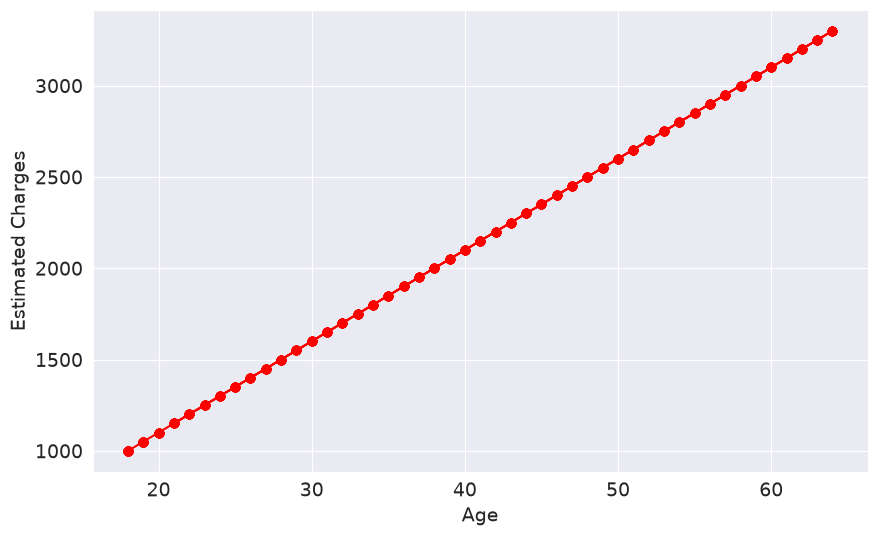

In [ ]:
# Visualize predictions: red line ('r'), solid connect ('-'), circle points ('o').
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age')
plt.ylabel('Estimated Charges')

As expected, the points lie on a straight line. 

We can overlay this line on the actual data, so see how well our _model_ fits the _data_.

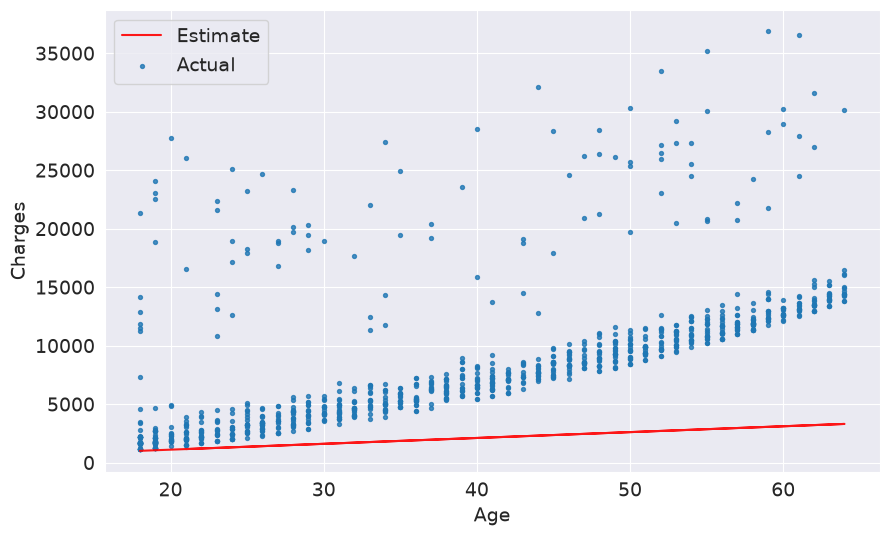

In [62]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8, alpha=0.8);
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [ ]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    
    estimated_charges = estimate_charges(ages, w, b)
    
    plt.plot(ages, estimated_charges, 'r', alpha=0.9); # 'r' = red
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

## Visualizing the Fit

When you manually adjust the parameters in `try_parameters(w, b)`:

* Changing **$w$** rotates the line (making it steeper or flatter).
* Changing **$b$** moves the line vertically (up or down).

The goal of the Linear Regression algorithm (using `.fit()` or Gradient Descent later) is to automatically find the values of **$w$** and **$b$** that minimize the distance between the **red line** (predictions) and the **blue dots** (actual data).


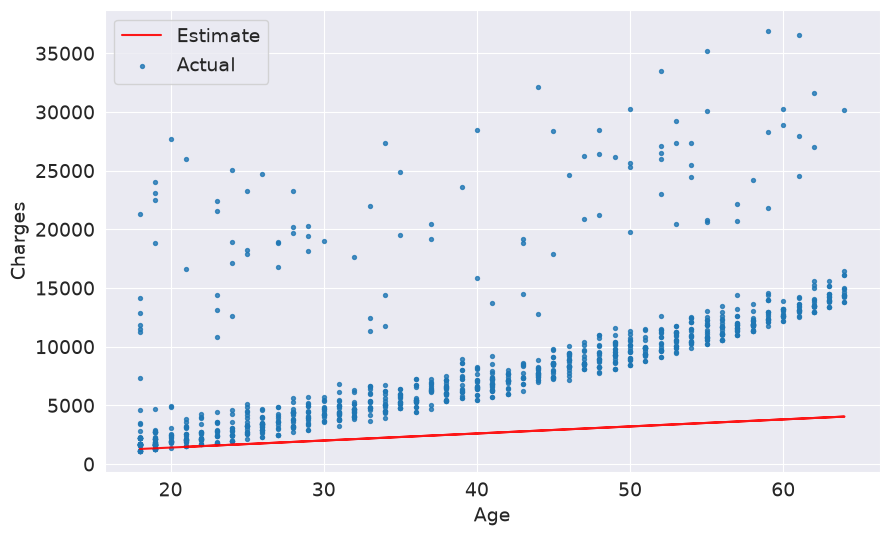

In [65]:
try_parameters(60, 200)

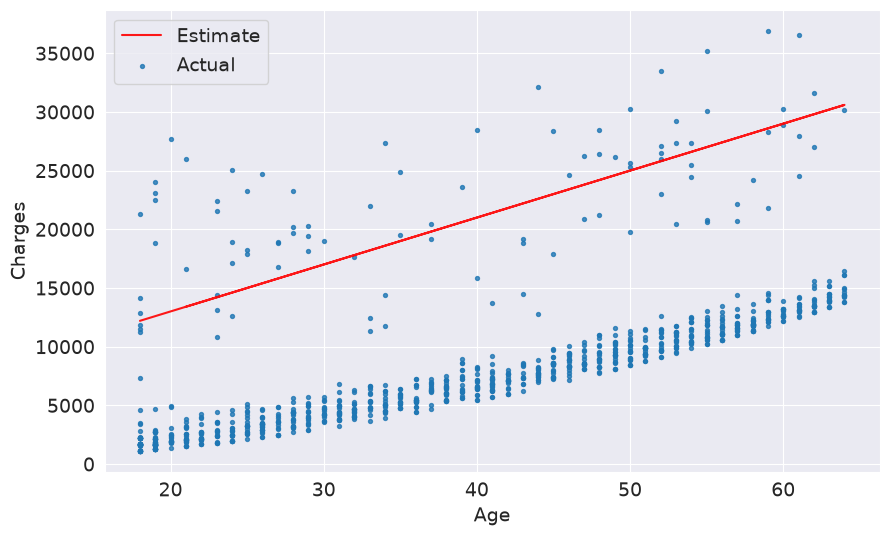

In [87]:
try_parameters(400, 5000)